In [1]:
library(ggplot2)
library(data.table)
theme_set(theme_bw())

# Source - https://stackoverflow.com/a
# Posted by dfrankow
# Retrieved 2026-01-16, License - CC BY-SA 3.0

options(repr.matrix.max.rows=600, repr.matrix.max.cols=200)

options(repr.plot.width = 10)

In [2]:
novelties = c(0.5, 0.95, 1.25)
communities = paste0('marine', seq(0, length(novelties) - 1), "novelty", novelties)
d1b = data.table(expand.grid(community = communities,
                             ts = 0, tg = 0, tf = 0, to = 0, tc = 0,
                             tp = 0, td = 0, tr = 0,
                             mask = seq(0, 4), setb = 1))
d1r = data.table(expand.grid(community = communities,
                             ts = 0, tg = 0, tf = 0, to = 0, tc = 0,
                             tp = 0, td = 0, tr = c(0, 0.1),
                             mask = seq(0, 4), setr = 1))
d1g = data.table(expand.grid(community = communities,
                             ts = 0.0,
                             tg = c(0.0, 0.01, 0.1, 1.0, 10.0),
                             tf = 5000.0, to = 0.0, tc = 0.0,
                             tp = 0.0, td = 0.0, tr = 0.0,
                             mask = seq(0, 4), setg = 1))
d1g[, tf := round(tf - tg - ts, 4)]
d1s = data.table(expand.grid(community = communities,
                             ts = c(0.0, 0.01, 0.1, 1.0, 10.0, 100.0),
                             tg = 5000.0, tf = 0.0,
                             to = 0.0, tc = 0.0,
                             tp = 0.0, td = 0.0, tr = 0.0,
                             mask = seq(0, 4), sets = 1))
d1s[, tg := round(tg - ts, 4)]
d1p = data.table(expand.grid(community = communities,
                             ts = 0.3, tg = 0.3, tf = 0.3, to = 0.3, tc = 0.3,
                             tp = c(0.1, 0.2, 0.3, 0.4, 0.5, 0.6), td = 2.8,
                             tr = 3.1,
                             mask = seq(0, 4), setp = 1))
d1p[, td := round(td - tp - tc - to - tf - tg - ts, 5)]
d1p[, tr := round(tr - td - tp - tc - to - tf - tg - ts, 5)]
#d1 = merge(merge(d1ar, d1d, all = TRUE), d1p, all = TRUE)
d1 = merge(merge(d1s, d1g, all = TRUE), d1b, all = TRUE)
dim(d1)

[1] 180  13

In [ ]:
# load opal metrics: Bray-Curtis distance, etc.
readit = function(community, ts, tg, tf, to, tc, tp, td, tr, mask){
    ff <- function(x) format(x, nsmall = 1)
    to_read = paste0('output_singlem_dev/opal/tune_s', ff(ts), 'g', ff(tg),
                     'f', ff(tf), 'o', ff(to), 'c', ff(tc),
                     'p', ff(tp), 'd', ff(td), 'r', ff(tr),
                     'mask', mask, '/', community,'.opal_report')
    #if (!file.exists(to_read)) return()
    return(fread(to_read))
}
d2 = d1[, readit(community, ts, tg, tf, to, tc, tp, td, tr, mask),
        by = d1]

In [ ]:
#d2 = data.table(community = communities[1], ts = 0.1, tg = 0,
#                tf = 0, to = 0, tc = 0, tp = 0, td = 0, tr = 0,
#                mask = 0)[, readit(community, ts, tg, tf, to, tc, tp, td, tr, mask),
#                          by = list(community, ts, tg, tf, to, tc, tp, td, tr, mask)]
dim(d2)
d2[1:5,]

[1] 32760    18

community,ts,tg,tf,to,tc,tp,td,tr,mask,sets,setg,setb,tool,rank,metric,sample,value
<fct>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<int>,<dbl>,<dbl>,<dbl>,<chr>,<chr>,<chr>,<chr>,<dbl>
marine0novelty0.5,0,0,0,0,0,0,0,0,0,NA,NA,1,Gold standard,kingdom,Bray-Curtis distance,SAMPLEID,0
marine0novelty0.5,0,0,0,0,0,0,0,0,0,NA,NA,1,Gold standard,phylum,Bray-Curtis distance,SAMPLEID,0
marine0novelty0.5,0,0,0,0,0,0,0,0,0,NA,NA,1,Gold standard,class,Bray-Curtis distance,SAMPLEID,0
marine0novelty0.5,0,0,0,0,0,0,0,0,0,NA,NA,1,Gold standard,order,Bray-Curtis distance,SAMPLEID,0
marine0novelty0.5,0,0,0,0,0,0,0,0,0,NA,NA,1,Gold standard,family,Bray-Curtis distance,SAMPLEID,0


In [ ]:
s1 = d2[tool != "Gold standard" & metric == "Bray-Curtis distance"]
s1[, rank := factor(rank, c('kingdom','phylum','class','order','family','genus','species'))]
setnames(s1, "value", "Bray-Curtis distance")

In [ ]:
plot_bc <- function(data, by) {
   ggplot(data, aes(rank, `Bray-Curtis distance`, colour = factor({{ by }}))) +
      geom_boxplot() +
      scale_x_discrete(na.translate = FALSE) +
      theme(axis.text.x = element_text(angle = 45, hjust = 1)) +
      theme(legend.title=element_blank()) +
      #theme(legend.position=c(0.1,0.4)) +
      theme(legend.background = element_rect(colour = "black", linewidth = 0.3))
}

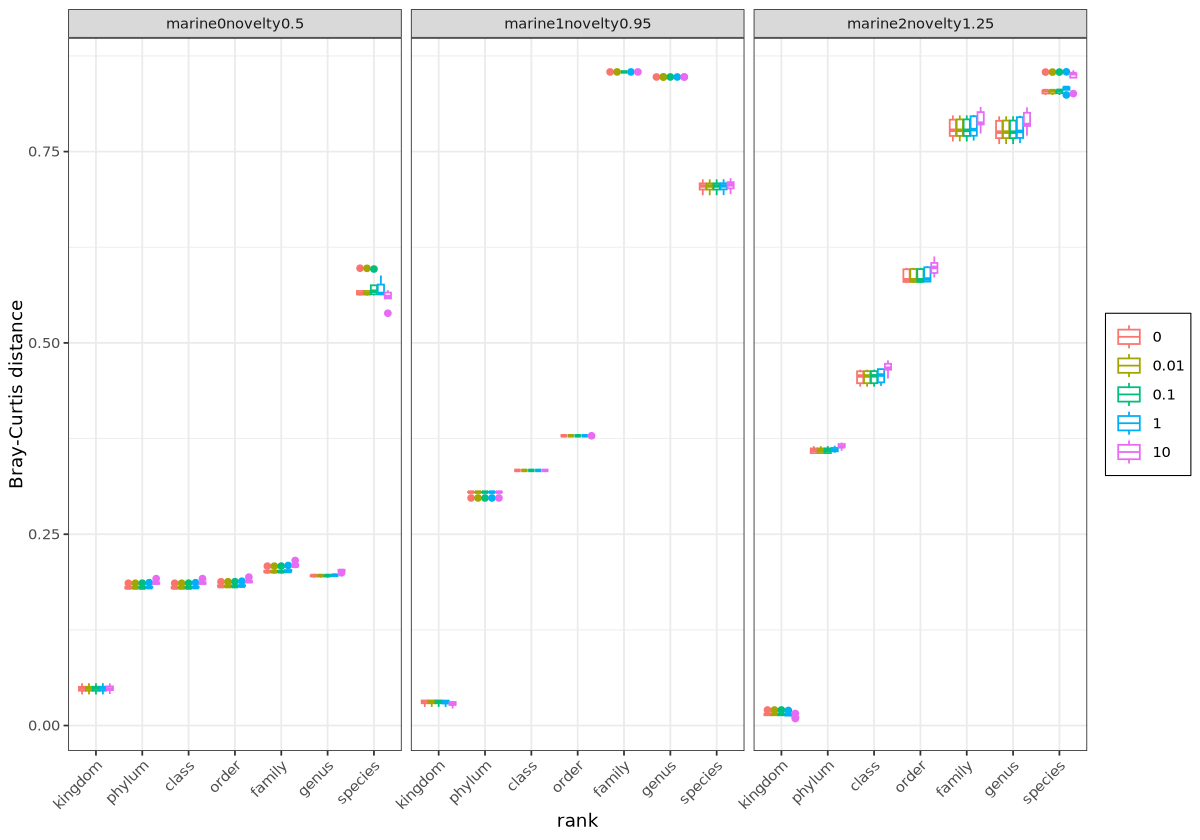

In [ ]:
plot_bc(s1[setg == 1], by = tg) + facet_wrap(vars(community))

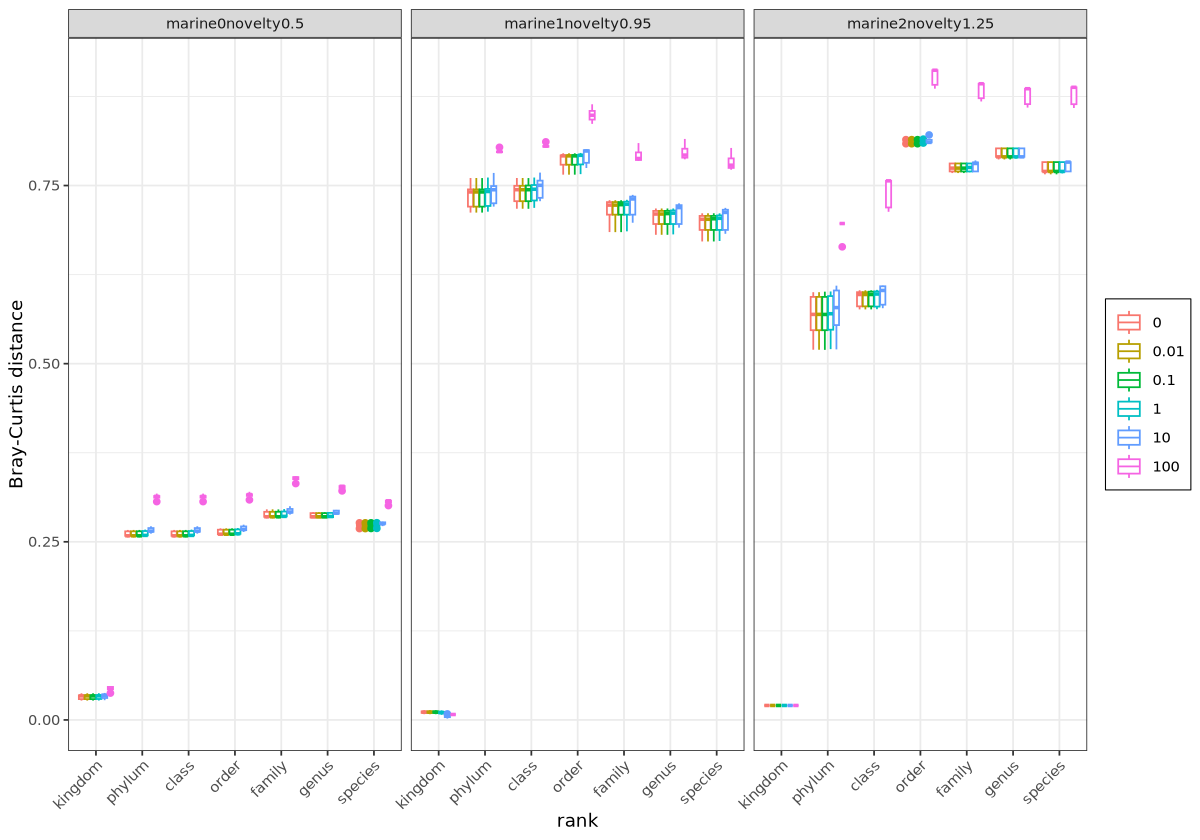

In [ ]:
plot_bc(s1[sets == 1], by = ts) + facet_wrap(vars(community))

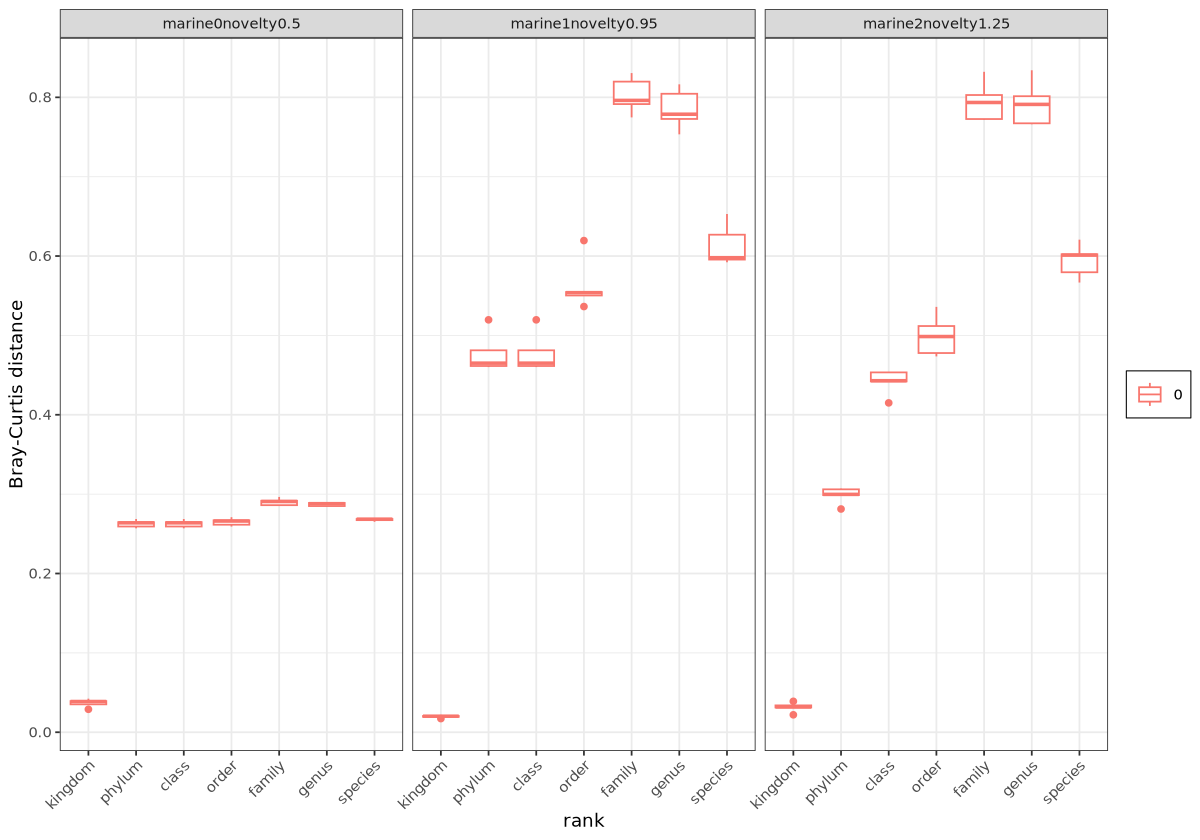

In [ ]:
plot_bc(s1[setb == 1]) + facet_wrap(vars(community))

## Compare profiles

In [ ]:
truth_profiles = data.table(community=communities)
truth_profiles2 = truth_profiles[, fread(paste('truths/',community,'.condensed',sep='')), by=community]
truth_profiles2[, c("sample", "tool") := .(NULL, 'Gold standard')]

In [ ]:
readprof = function(community, ts, tg, tf, to, tc, tp, td, tr, mask){
    ff <- function(x) format(x, nsmall = 1)
    to_read = paste0('output_singlem_dev/singlem_dev/tune_s', ff(ts), 'g', ff(tg),
                     'f', ff(tf), 'o', ff(to), 'c', ff(tc),
                     'p', ff(tp), 'd', ff(td), 'r', ff(tr),
                     'mask', mask, '/', community,'.profile')
    #if (!file.exists(to_read)) return()
    return(fread(to_read))
}
tool_profiles_sm = data.table(community = communities)
tool_profiles_sm2 = truth_profiles[
    ,
    fread(paste('output_singlem/singlem/',community,'.profile',sep='')),
    by=list(community)
]
tool_profiles_sm2[
    ,
    `:=`(sample = NULL,
         taxonomy = gsub('Root;','',gsub('; ',';',taxonomy)),
         tool = "singlem")
]

all_profiles = rbind(truth_profiles2, tool_profiles_sm2)
all_profiles[, relabu := coverage / sum(coverage), by = list(community, tool)]
m = dcast(all_profiles, taxonomy + community ~ tool, value.var = c("relabu", "coverage"), fill = 0)
setnames(m, names(m), gsub("_", "__", names(m)))
setnames(m, c("relabu__Gold standard", "coverage__Gold standard"), c("true_relabu", "true_coverage"))

In [ ]:
tool_profiles_dev2 = d1[
    ,
    readprof(community, ts, tg, tf, to, tc, tp, td, tr, mask),
    by=d1
]
tool_profiles_dev2[
    ,
    `:=`(sample = NULL,
         taxonomy = gsub('Root;','',gsub('; ',';',taxonomy)),
         tool = "singlem_dev")
]
tool_profiles_dev3 = tool_profiles_dev2[
    ,
    list(coverage = median(coverage), relabu = median(coverage / sum(coverage))),
    by = list(community, ts, tg, tf, to, tc, tp, td, tr, taxonomy, tool, setb, sets)
]
tool_profiles_dev3[, tg := tg + ts]
tool_profiles_dev3[, tf := tf + tg]
tool_profiles_dev3[, to := to + tf]
tool_profiles_dev3[, tc := tc + to]
tool_profiles_dev3[, tp := tp + tc]
tool_profiles_dev3[, td := td + tp]
tool_profiles_dev3[, tr := tr + td]
m_dev_s = dcast(tool_profiles_dev3[sets == 1], taxonomy + community + tg + tf + to + tc + tp + td + tr ~ tool + ts, value.var = c("relabu", "coverage"), fill = 0)
m_dev_b = dcast(tool_profiles_dev3[setb == 1], taxonomy + community ~ tool, value.var = c("relabu", "coverage"), fill = 0)

In [ ]:
m2 = merge(m, merge(m_dev_b, m_dev_s, by = c("taxonomy", "community")), by = c("taxonomy", "community"))
head(m2)

taxonomy,community,true_relabu,relabu__singlem,true_coverage,coverage__singlem,relabu_singlem_dev,coverage_singlem_dev,tg,tf,to,tc,tp,td,tr,relabu_singlem_dev_0,relabu_singlem_dev_0.01,relabu_singlem_dev_0.1,relabu_singlem_dev_1,relabu_singlem_dev_10,relabu_singlem_dev_100,coverage_singlem_dev_0,coverage_singlem_dev_0.01,coverage_singlem_dev_0.1,coverage_singlem_dev_1,coverage_singlem_dev_10,coverage_singlem_dev_100
<chr>,<chr>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>
d__Archaea;p__Thermoplasmatota;c__Thermoplasmata;o__ARK-15;f__ARK-15;g__ARK-15;s__ARK-15 sp009758405,marine0novelty0.5,0.143568212,0.140885984,29.71980,29.10,0.2012162,25.81,5000,5000,5000,5000,5000,5000,5000,0.2007779,0.2007779,0.2008091,0.2007945,0.2009920,0.2016122,25.810,25.810,25.81,25.780,25.53,23.01
d__Bacteria;p__Bacteroidota;c__Bacteroidia;o__Flavobacteriales;f__Flavobacteriaceae;g__Capnocytophaga;s__Capnocytophaga canimorsus,marine0novelty0.5,0.200240841,0.200290487,41.45150,41.37,0.1980108,41.41,5000,5000,5000,5000,5000,5000,5000,0.1980566,0.1980566,0.1980373,0.1980826,0.1982917,0.2000751,41.580,41.580,41.57,41.530,41.09,37.29
d__Bacteria;p__Firmicutes;c__Bacilli;o__Lactobacillales;f__Lactobacillaceae;g__Lactobacillus;s__Lactobacillus acidophilus,marine0novelty0.5,0.006487375,0.007697894,1.34294,1.59,1.0000000,0.05,5000,5000,5000,5000,5000,5000,5000,0.5000000,0.5000000,0.5000000,0.5000000,1.0000000,0.0000000,0.155,0.155,0.15,0.145,0.21,0.00
d__Bacteria;p__Firmicutes;c__Bacilli;o__Mycoplasmatales;f__Mycoplasmataceae;g__Mycoplasma;s__Mycoplasma capri,marine0novelty0.5,0.008910806,0.006584362,1.84461,1.36,1.0000000,0.13,5000,5000,5000,5000,5000,5000,5000,1.0000000,1.0000000,1.0000000,1.0000000,1.0000000,0.0000000,0.170,0.170,0.17,0.170,0.11,0.00
d__Bacteria;p__Firmicutes;c__Bacilli;o__Staphylococcales;f__Staphylococcaceae;g__Staphylococcus;s__Staphylococcus aureus,marine0novelty0.5,0.013567046,0.014669572,2.80849,3.03,0.2063622,2.53,5000,5000,5000,5000,5000,5000,5000,0.2055777,0.2055777,0.2057416,0.2057878,0.2077586,0.2393939,2.580,2.580,2.58,2.560,2.41,0.79
d__Bacteria;p__Firmicutes_A;c__Clostridia;o__Peptostreptococcales;f__Peptostreptococcaceae;g__Clostridium_Y;s__Clostridium_Y paradoxum,marine0novelty0.5,0.050569489,0.051174050,10.46830,10.57,0.1993931,11.17,5000,5000,5000,5000,5000,5000,5000,0.1996457,0.1996457,0.1996457,0.1998224,0.2008399,0.1994576,11.270,11.270,11.27,11.250,11.00,8.09


In [ ]:
# singlem coverages
format_table_cov <- function(m) {
    cov_cols <- grep("sylph", grep("^coverage_|_coverage$", names(m), value = TRUE), invert = TRUE, value = TRUE)
    mtmp = m[, which(!grepl("^relabu_|_relabu$", names(m)) & !grepl("sylph", names(m))), with = FALSE]
    mtmp[
        ,
        c(cov_cols, "taxonomy") := c(
            .SD,
            list(purrr::map_chr(strsplit(taxonomy, "; ?"), function(x) paste0(tail(x,2), collapse = "; ")))
        ),
        .SDcols = cov_cols
    ][]
}

In [ ]:
# kingdom
format_table_cov(m2[grep("d__", taxonomy), lapply(.SD, sum), by = list(community, taxonomy = gsub(";p__.*", "", taxonomy), tg, tf, to, tc, tp, td, tr)])

community,taxonomy,tg,tf,to,tc,tp,td,tr,true_coverage,coverage__singlem,coverage_singlem_dev,coverage_singlem_dev_0,coverage_singlem_dev_0.01,coverage_singlem_dev_0.1,coverage_singlem_dev_1,coverage_singlem_dev_10,coverage_singlem_dev_100
<chr>,<chr>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>
marine0novelty0.5,d__Archaea,5000,5000,5000,5000,5000,5000,5000,29.71980,29.10,25.810,25.810,25.810,25.810,25.780,25.53,23.01
marine0novelty0.5,d__Bacteria,5000,5000,5000,5000,5000,5000,5000,120.39349,117.82,105.645,106.665,106.665,106.645,106.465,104.68,87.96
marine1novelty0.95,d__Bacteria,5000,5000,5000,5000,5000,5000,5000,18.00950,16.82,12.835,15.970,15.960,15.960,15.900,15.40,11.19
marine2novelty1.25,d__Bacteria,5000,5000,5000,5000,5000,5000,5000,12.29161,11.78,4.600,8.740,8.740,8.740,8.710,8.42,5.14


In [ ]:
# species
format_table_cov(m2[grep("d__", taxonomy), lapply(.SD, sum), by = list(community, taxonomy = taxonomy, tg, tf, to, tc, tp, td, tr)])

community,taxonomy,tg,tf,to,tc,tp,td,tr,true_coverage,coverage__singlem,coverage_singlem_dev,coverage_singlem_dev_0,coverage_singlem_dev_0.01,coverage_singlem_dev_0.1,coverage_singlem_dev_1,coverage_singlem_dev_10,coverage_singlem_dev_100
<chr>,<chr>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>
marine0novelty0.5,g__ARK-15; s__ARK-15 sp009758405,5000,5000,5000,5000,5000,5000,5000,29.71980,29.10,25.810,25.810,25.810,25.810,25.780,25.53,23.01
marine0novelty0.5,g__Capnocytophaga; s__Capnocytophaga canimorsus,5000,5000,5000,5000,5000,5000,5000,41.45150,41.37,41.410,41.580,41.580,41.570,41.530,41.09,37.29
marine0novelty0.5,g__Lactobacillus; s__Lactobacillus acidophilus,5000,5000,5000,5000,5000,5000,5000,1.34294,1.59,0.050,0.155,0.155,0.150,0.145,0.21,0.00
marine0novelty0.5,g__Mycoplasma; s__Mycoplasma capri,5000,5000,5000,5000,5000,5000,5000,1.84461,1.36,0.130,0.170,0.170,0.170,0.170,0.11,0.00
marine0novelty0.5,g__Staphylococcus; s__Staphylococcus aureus,5000,5000,5000,5000,5000,5000,5000,2.80849,3.03,2.530,2.580,2.580,2.580,2.560,2.41,0.79
marine0novelty0.5,g__Clostridium_Y; s__Clostridium_Y paradoxum,5000,5000,5000,5000,5000,5000,5000,10.46830,10.57,11.170,11.270,11.270,11.270,11.250,11.00,8.09
marine0novelty0.5,g__GCA-2724215; s__GCA-2724215 sp018672475,5000,5000,5000,5000,5000,5000,5000,46.32900,45.70,42.210,42.190,42.190,42.190,42.150,41.77,38.28
marine0novelty0.5,g__Bosea; s__Bosea vestrisii,5000,5000,5000,5000,5000,5000,5000,2.75543,2.64,1.680,1.790,1.790,1.790,1.780,1.69,0.63
marine0novelty0.5,g__Zymomonas; s__Zymomonas mobilis,5000,5000,5000,5000,5000,5000,5000,1.84739,1.25,0.100,0.140,0.140,0.135,0.130,0.06,0.00


# NMF penalty tuning

In [ ]:
# load SingleM loss metrics
readloss = function(community, ts, tg, tf, to, tc, tp, td, tr, mask){
    ff <- function(x) format(x, nsmall = 1)
    to_read = paste0('output_singlem_dev/singlem_dev/tune_s', ff(ts), 'g', ff(tg),
                     'f', ff(tf), 'o', ff(to), 'c', ff(tc),
                     'p', ff(tp), 'd', ff(td), 'r', ff(tr),
                     'mask', mask, '/', community,'.loss.tsv')
    #if (!file.exists(to_read)) return()
    return(fread(to_read, header = FALSE, col.names = c("metric", "value")))
}
d3 = d1[, readloss(community, ts, tg, tf, to, tc, tp, td, tr, mask),
        by=d1]

In [ ]:
#d2 = data.table(community = communities[1], ts = 0.1, tg = 0,
#                tf = 0, to = 0, tc = 0, tp = 0, td = 0, tr = 0,
#                mask = 0)[, readloss(community, ts, tg, tf, to, tc, tp, td, tr, mask),
#                          by = list(community, ts, tg, tf, to, tc, tp, td, tr, mask)]
d3[1:5,]

community,ts,tg,tf,to,tc,tp,td,tr,mask,sets,setg,setb,metric,value
<fct>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<int>,<dbl>,<dbl>,<dbl>,<chr>,<dbl>
marine0novelty0.5,0,0,0,0,0,0,0,0,0,NA,NA,1,NMF loss,13380.32
marine0novelty0.5,0,0,0,0,0,0,0,0,0,NA,NA,1,NMF mask loss,12964.30
marine0novelty0.5,0,0,0,0,0,0,0,0,0,NA,NA,1,NMF penalised loss,13380.32
marine0novelty0.5,0,0,0,0,0,0,0,0,0,NA,NA,1,NMF steps,39.00
marine0novelty0.5,0,0,0,0,0,0,0,0,1,NA,NA,1,NMF loss,16983.97


In [ ]:
# combine with Bray-Curtis distances
s1_bcr = s1[, names(s1)[!names(s1) %in% c("metric", "tool", "sample")], with = FALSE]
s1_bcr[, c("metric", "rank", "value", "Bray-Curtis distance") := list(paste0("BC ", rank), NULL, `Bray-Curtis distance`, NULL)]
d4 = rbind(d3, s1_bcr)
d4[1:5]

community,ts,tg,tf,to,tc,tp,td,tr,mask,sets,setg,setb,metric,value
<fct>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<int>,<dbl>,<dbl>,<dbl>,<chr>,<dbl>
marine0novelty0.5,0,0,0,0,0,0,0,0,0,NA,NA,1,NMF loss,13380.32
marine0novelty0.5,0,0,0,0,0,0,0,0,0,NA,NA,1,NMF mask loss,12964.30
marine0novelty0.5,0,0,0,0,0,0,0,0,0,NA,NA,1,NMF penalised loss,13380.32
marine0novelty0.5,0,0,0,0,0,0,0,0,0,NA,NA,1,NMF steps,39.00
marine0novelty0.5,0,0,0,0,0,0,0,0,1,NA,NA,1,NMF loss,16983.97


In [ ]:
# spread NMF steps into separate column (for highlighting slow convergence)
d4_steps = d4[metric == "NMF steps"]
d4_steps[, metric := NULL]
setnames(d4_steps, "value", "steps")
d5 = d4[!metric %in% c("NMF steps", "NMF penalised loss"), ][d4_steps, on = .NATURAL]
d5[1:5]

community,ts,tg,tf,to,tc,tp,td,tr,mask,sets,setg,setb,metric,value,steps
<fct>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<int>,<dbl>,<dbl>,<dbl>,<chr>,<dbl>,<dbl>
marine0novelty0.5,0,0,0,0,0,0,0,0,0,NA,NA,1,NMF loss,1.338032e+04,39
marine0novelty0.5,0,0,0,0,0,0,0,0,0,NA,NA,1,NMF mask loss,1.296430e+04,39
marine0novelty0.5,0,0,0,0,0,0,0,0,0,NA,NA,1,BC kingdom,2.891403e-02,39
marine0novelty0.5,0,0,0,0,0,0,0,0,0,NA,NA,1,BC phylum,2.569371e-01,39
marine0novelty0.5,0,0,0,0,0,0,0,0,0,NA,NA,1,BC class,2.569371e-01,39


In [ ]:
# calculate mask loss totals and loss metric and Bray-Curtis averages over the 5 mask runs (cross-validation)
s2 = d5[,
        list(value = sum(value), steps = max(steps)),
        by = d5[, -c("value", "steps", "mask")]]
s2[metric == "NMF loss", value := value / 4] # loss calculated with 4/5 of each run 
s2[startsWith(metric, "BC"), value := value / 5]
s2[1:5]

community,ts,tg,tf,to,tc,tp,td,tr,sets,setg,setb,metric,value,steps
<fct>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<chr>,<dbl>,<dbl>
marine0novelty0.5,0,0,0,0,0,0,0,0,NA,NA,1,NMF loss,2.003342e+04,47
marine0novelty0.5,0,0,0,0,0,0,0,0,NA,NA,1,NMF mask loss,5.600743e+04,47
marine0novelty0.5,0,0,0,0,0,0,0,0,NA,NA,1,BC kingdom,3.686331e-02,47
marine0novelty0.5,0,0,0,0,0,0,0,0,NA,NA,1,BC phylum,2.626687e-01,47
marine0novelty0.5,0,0,0,0,0,0,0,0,NA,NA,1,BC class,2.626687e-01,47


In [ ]:
# we scale all the metrics and plot together to look for minimums/elbows
scale <- function(data) {
    data[, `:=`(min = min(value), max = max(value)), by = list(metric)]
    data[, value := ifelse(min == max, 0.5, (value - min) / (max - min))]
}
plot_slope <- function(data, x) {
    ggplot(data, aes({{ x }}, value, colour = metric,
                     alpha = steps < 5000, group = metric)) +
    geom_point() +
    geom_line() +
    scale_alpha_discrete(limits = c(FALSE, TRUE)) +
    #scale_x_continuous(transform = scales::transform_reciprocal()) +
    facet_wrap(vars(community))+#, scales = "free_y") +
    theme(legend.title=element_blank()) +
    theme(legend.position="bottom") +
    theme(legend.background = element_rect(colour = "black", linewidth = 0.3))
}

Warning message:
“Using alpha for a discrete variable is not advised.”


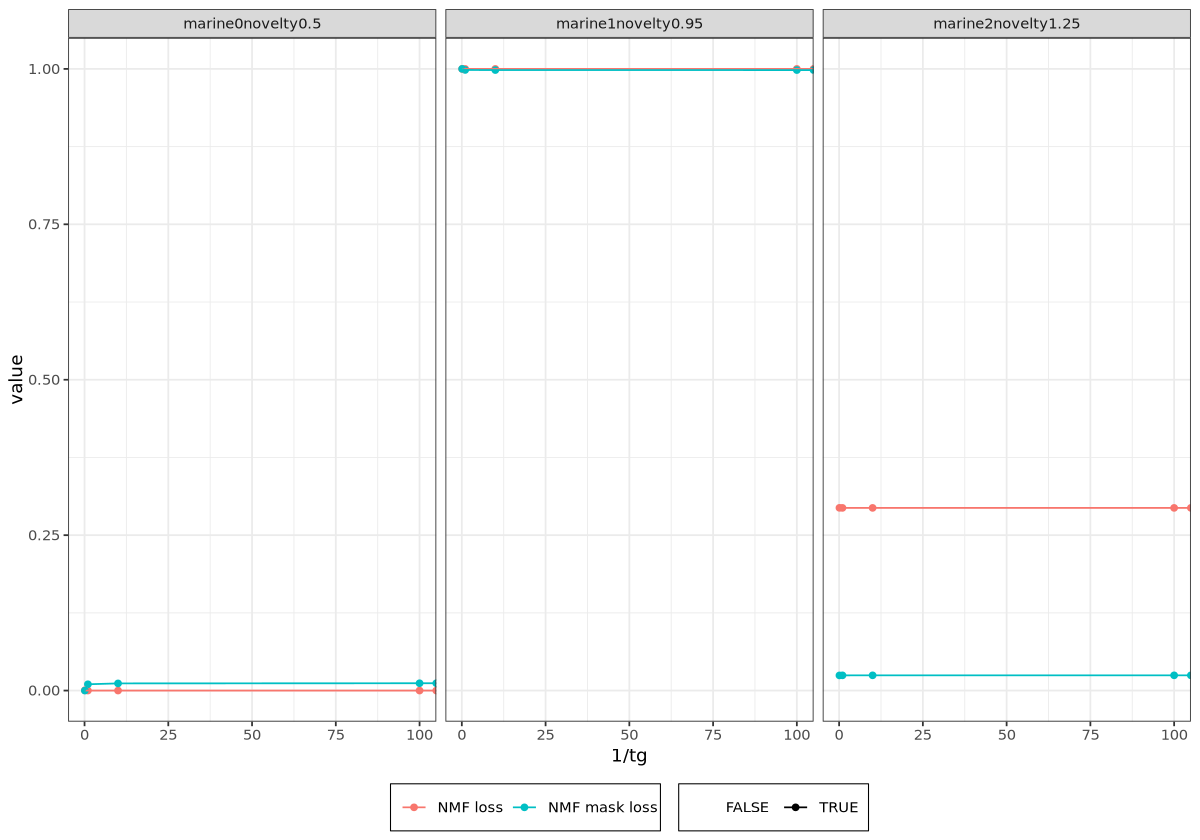

In [ ]:
plot_slope(scale(s2[setg == 1 & !startsWith(metric, "BC")]), 1/tg)

Warning message:
“Using alpha for a discrete variable is not advised.”


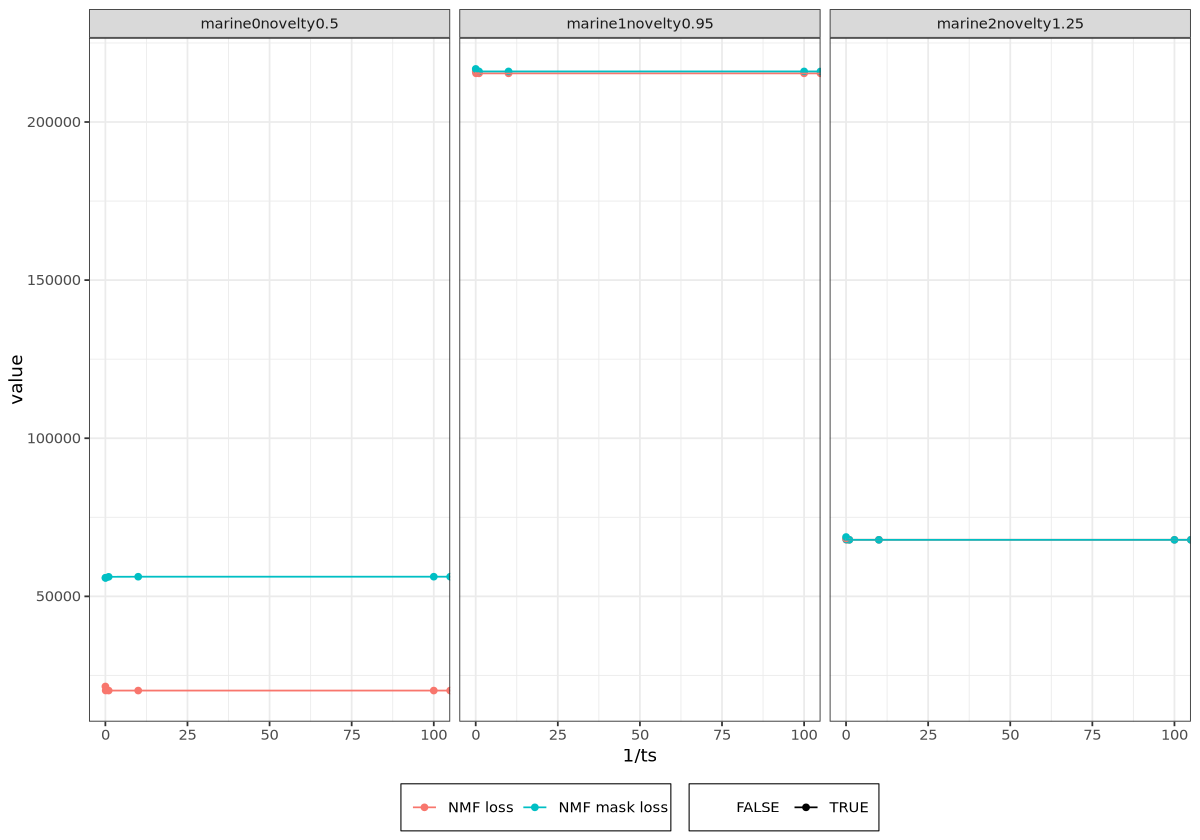

In [ ]:
plot_slope(s2[sets == 1 & (!startsWith(metric, "BC"))], 1/ts)

# Diamond percent identity distribution

In [3]:
d1 = data.table(community = communities)

# load opal metrics: Bray-Curtis distance, etc.
readit = function(community){
    to_read <- paste0('output_singlem_dev/singlem_dev/', community,'.sma')
    m <- jsonlite::read_json(to_read)
    
}

In [ ]:
m <- jsonlite::read_json("output_singlem_dev/singlem_dev/marine0novelty0.5.sma")
stopifnot(m$fields[14] == "percent_identities")
pids <- purrr::map(m$otus, \(x) x[[14]])

In [12]:
sum(lengths(pids))
length(pids)

[1] 730

[1] 2062

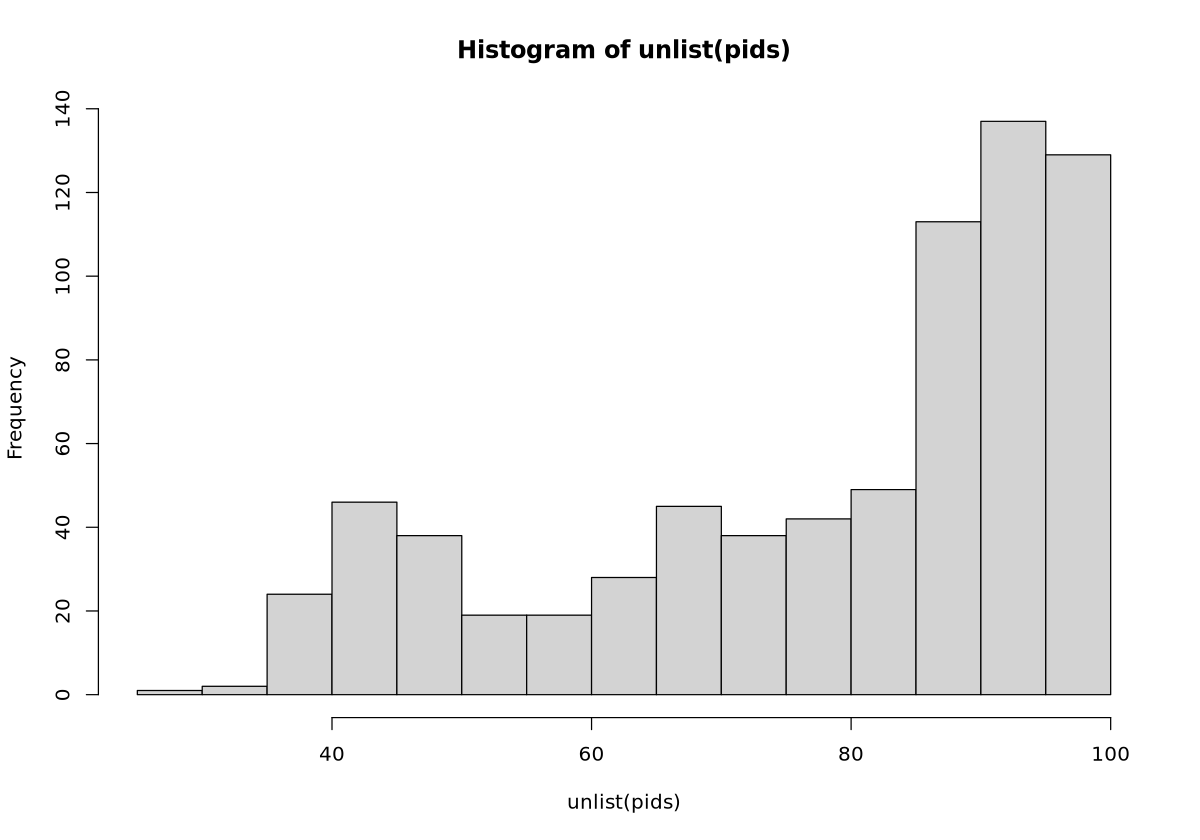

In [14]:
hist(unlist(pids))

In [ ]:

readit(communities[1])
d2 = d1[, readit(community), by = d1]